In [144]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px


In [145]:
ano = 2024
data_dir = Path("data")
INDIR = Path("../data/data_model")
OUTDIR_IMG = Path(f"../report/img/{ano}")
OUTDIR_IMG.mkdir(parents=True, exist_ok=True)

In [146]:
arquivo = INDIR / f"ANALISE_NOTAS_ENEM_MUNICIPIOS_BRASIL_CLUSTERS_{ano}.csv"
df = pd.read_csv(arquivo, sep=",")

In [147]:
df.head()

,NO_MUNICIPIO_PROVA,UF,QTD_PARTICIPANTES,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,MEDIA_GERAL,RENDA_FAMILIAR_SM_MEDIA,CLUSTER
0,ABAETETUBA,PA,4890,461.314479,466.065501,483.305317,473.035583,586.355828,494.015342,1.253781,0
1,ABAETÉ,MG,546,492.137179,523.886996,539.278022,547.032601,667.326007,553.932161,2.451439,2
2,ABREU E LIMA,PE,1810,473.122486,493.848674,513.249448,493.806796,589.690608,512.743602,1.359065,1
3,ACARAPE,CE,410,464.850244,480.734878,500.530488,501.268537,622.585366,513.993902,1.005342,1
4,ACARAÚ,CE,1141,473.460035,479.478002,499.146012,521.760649,683.032428,531.375425,1.161161,1


In [148]:
df_dict_municipio = {
    0: df[df['CLUSTER'] == 0].copy().reset_index(drop=True),
    1: df[df['CLUSTER'] == 1].copy().reset_index(drop=True),
    2: df[df['CLUSTER'] == 2].copy().reset_index(drop=True)
}

Imagem salva em: ../report/img/2024/2024_DISTRIBUICAO_DAS_MEDIAS_DE_NOTAS_POR_CLUSTER.png


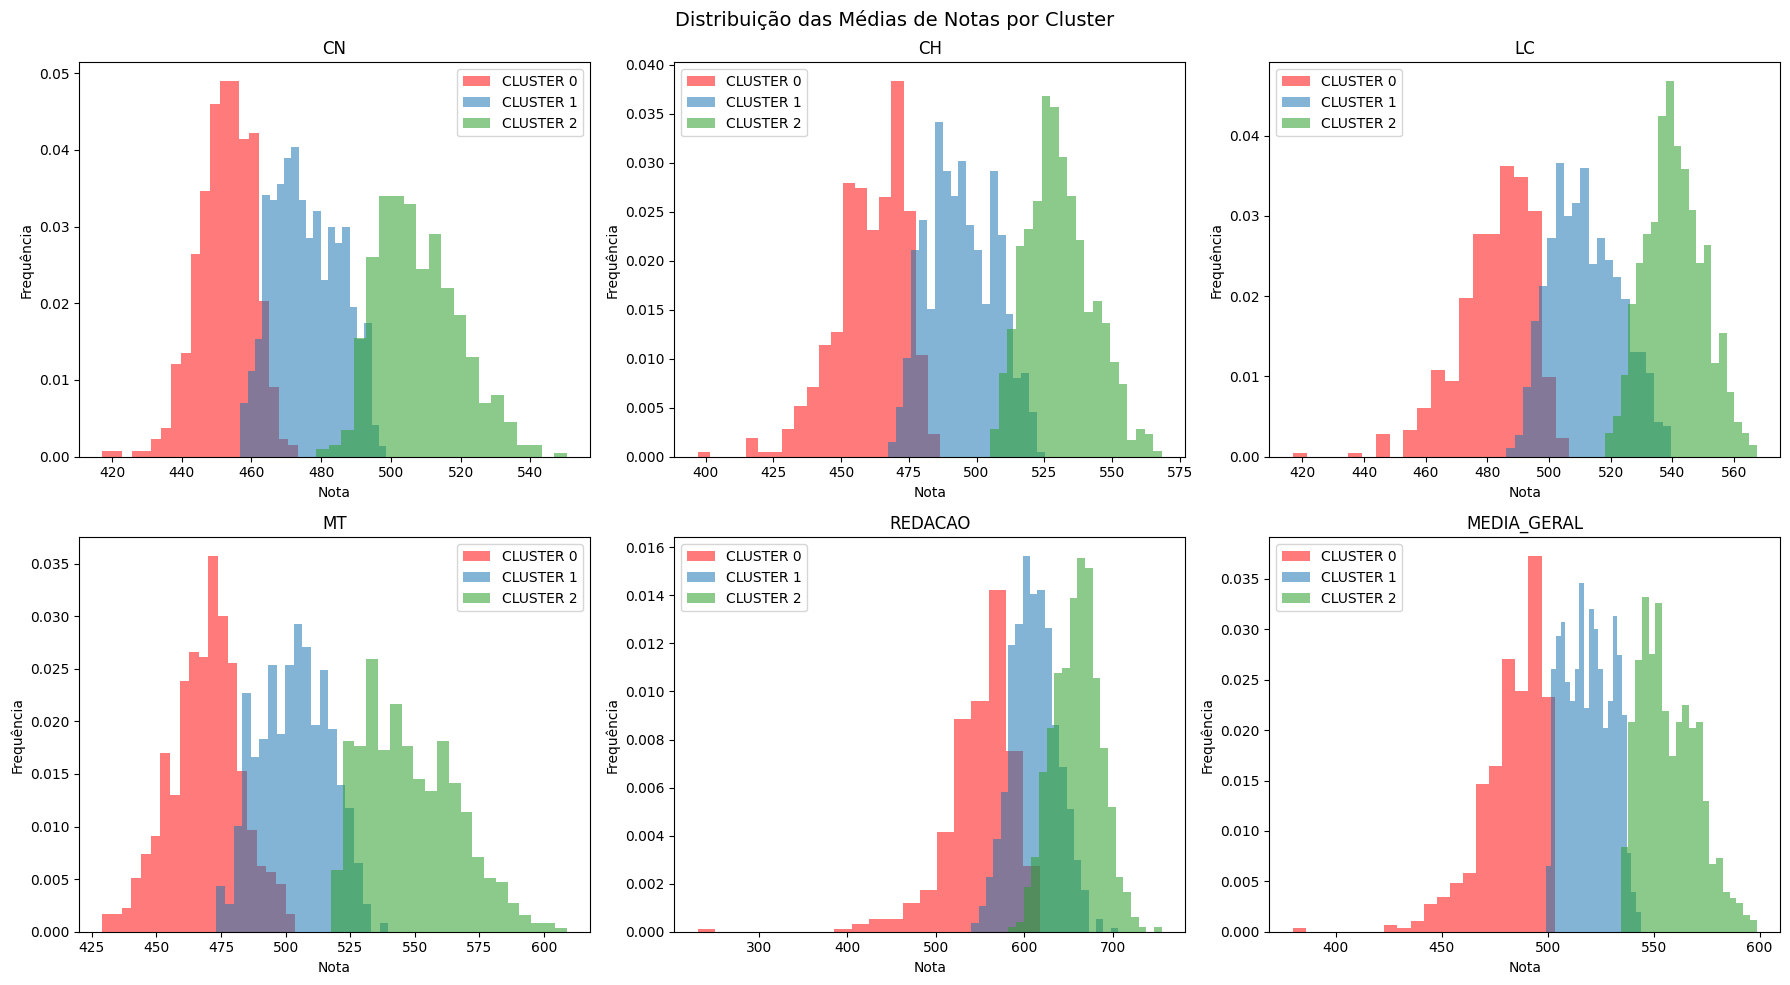

In [149]:
colunas_notas = [c for c in df.columns if c.startswith("NU_NOTA_") and c.endswith("_MEDIA")]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cores_cluster = {0: "#ff0e0e", 1: "#1f77b4", 2: "#2ca02c"}
coluna_extra = next((c for c in ["MEDIA_GERAL", "MED9A_GERAL"] if c in df.columns), None)
if coluna_extra and coluna_extra not in colunas_notas:
    colunas_notas.append(coluna_extra)
for i, coluna in enumerate(colunas_notas):
    ax = axes[i]
    for cluster in sorted(df["CLUSTER"].unique()):
        ax.hist(
            df.loc[df["CLUSTER"] == cluster, coluna],
            bins=20,
            alpha=0.55,
            label=f"CLUSTER {cluster}",
            color=cores_cluster.get(cluster, None),
            density=True
        )
    ax.set_title(coluna.replace("NU_NOTA_", "").replace("_MEDIA", ""))
    ax.set_xlabel("Nota")
    ax.set_ylabel("Frequência")
    ax.legend()

for j in range(len(colunas_notas), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribuição das Médias de Notas por Cluster", fontsize=14)
plt.tight_layout()
caminho = OUTDIR_IMG / f"{ano}_DISTRIBUICAO_DAS_MEDIAS_DE_NOTAS_POR_CLUSTER.png"
fig.savefig(caminho, dpi=300, bbox_inches="tight")
print(f"Imagem salva em: {caminho}")
plt.show()

In [150]:
df.head()

,NO_MUNICIPIO_PROVA,UF,QTD_PARTICIPANTES,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,MEDIA_GERAL,RENDA_FAMILIAR_SM_MEDIA,CLUSTER
0,ABAETETUBA,PA,4890,461.314479,466.065501,483.305317,473.035583,586.355828,494.015342,1.253781,0
1,ABAETÉ,MG,546,492.137179,523.886996,539.278022,547.032601,667.326007,553.932161,2.451439,2
2,ABREU E LIMA,PE,1810,473.122486,493.848674,513.249448,493.806796,589.690608,512.743602,1.359065,1
3,ACARAPE,CE,410,464.850244,480.734878,500.530488,501.268537,622.585366,513.993902,1.005342,1
4,ACARAÚ,CE,1141,473.460035,479.478002,499.146012,521.760649,683.032428,531.375425,1.161161,1


In [151]:
renda_col = "RENDA_FAMILIAR_SM_MEDIA"

titulos = []
for c in colunas_notas:
    base = c.replace("NU_NOTA_", "").replace("_MEDIA", "")
    d = df[[renda_col, c]].dropna()
    corr = d[renda_col].corr(d[c])
    titulos.append(f"{base} (r={corr:.3f})")

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=titulos,
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

for i, coluna in enumerate(colunas_notas):
    row = i // 3 + 1
    col = i % 3 + 1

    for cluster in sorted(df["CLUSTER"].unique()):
        dados = df[df["CLUSTER"] == cluster]
        dados_validos = dados[[renda_col, coluna, "NO_MUNICIPIO_PROVA", "UF", "QTD_PARTICIPANTES"]].dropna()

        fig.add_trace(
            go.Scatter(
                x=dados_validos[renda_col],
                y=dados_validos[coluna],
                mode="markers",
                marker=dict(size=6, color=cores_cluster.get(cluster)),
                opacity=0.7,
                name=f"CLUSTER {cluster}",
                showlegend=(i == 0),
                customdata=dados_validos[["NO_MUNICIPIO_PROVA", "UF", "QTD_PARTICIPANTES"]],
                hovertemplate=(
                    "Município: %{customdata[0]} (%{customdata[1]})<br>"
                    "Renda: %{x:.2f}<br>"
                    "Nota: %{y:.2f}<br>"
                    "Participantes: %{customdata[2]}<br>"
                    f"Cluster: {cluster}"
                    "<extra></extra>"
                )
            ),
            row=row,
            col=col
        )

    fig.update_xaxes(title_text="Renda Familiar Média (SM)", row=row, col=col)
    fig.update_yaxes(title_text="Nota Média", row=row, col=col)

fig.update_layout(
    title=f"Relação entre Renda Familiar Média e Notas por Cluster (ENEM {ano})",
    height=800,
    width=1200,
    template="plotly_white"
)

caminho = OUTDIR_IMG / f"{ano}_RELACAO_ENTRE_RENDA_FAMILIAR_MEDIA_E_NOTAS_POR_CLUSTER.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
fig.show()


Imagem salva em: ../report/img/2024/2024_RELACAO_ENTRE_RENDA_FAMILIAR_MEDIA_E_NOTAS_POR_CLUSTER.png


In [152]:
def media_ponderada(grupo, coluna, peso="QTD_PARTICIPANTES"):
    d = grupo[[coluna, peso]].dropna()
    soma_pesos = d[peso].sum()
    return (d[coluna] * d[peso]).sum() / soma_pesos if soma_pesos != 0 else pd.NA

df_uf = (
    df.groupby("UF")
    .apply(
        lambda g: pd.Series(
            {
                "QTD_MUNICIPIOS": g["NO_MUNICIPIO_PROVA"].count(),
                "QTD_PARTICIPANTES": g["QTD_PARTICIPANTES"].sum(),
                "CLUSTER": g["CLUSTER"].mode().iloc[0] if not g["CLUSTER"].mode().empty else pd.NA,
                "RENDA_FAMILIAR_SM_MEDIA": g["RENDA_FAMILIAR_SM_MEDIA"].mean(),
                **{col: media_ponderada(g, col) for col in colunas_notas},
            }
        )
    )
    .reset_index()
    .sort_values("UF")
    .reset_index(drop=True)
)

df_dict_uf = {
    0: df_uf[df_uf['CLUSTER'] == 0].copy().reset_index(drop=True),
    1: df_uf[df_uf['CLUSTER'] == 1].copy().reset_index(drop=True),
    2: df_uf[df_uf['CLUSTER'] == 2].copy().reset_index(drop=True)
}

In [153]:

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"


In [154]:
df_map = df_dict_uf[0].copy()

fig = px.choropleth(
    df_map,
    geojson=url,
    locations='UF',
    featureidkey='properties.sigla',
    color='MEDIA_GERAL',
    color_continuous_scale='Reds_r',
    title=f'Estados com piores rendimentos (Cluster 0 - ENEM {ano})',
    custom_data=[
        'UF',
        'MEDIA_GERAL',
        'RENDA_FAMILIAR_SM_MEDIA',
        'QTD_PARTICIPANTES'
    ]
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_traces(
    hovertemplate=(
        "Estado: %{customdata[0]}<br>"
        "Média geral: %{customdata[1]:.2f}<br>"
        "Renda média: %{customdata[2]:.2f}<br>"
        "Participantes: %{customdata[3]}<br>"
        "<extra></extra>"
    )
)

caminho = OUTDIR_IMG / f"{ano}_ESTADOS_COM_PIORES_RENDIMENTOS_CLUSTER_0.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
fig.show()

Imagem salva em: ../report/img/2024/2024_ESTADOS_COM_PIORES_RENDIMENTOS_CLUSTER_0.png


In [155]:
df_map = df_dict_uf[2].copy()

fig = px.choropleth(
    df_map,
    geojson=url,
    locations='UF',
    featureidkey='properties.sigla',
    color='MEDIA_GERAL',
    color_continuous_scale='Greens',
    title=f'Estados com melhores rendimentos (Cluster 2 - ENEM {ano})',
    custom_data=[
        'UF',
        'MEDIA_GERAL',
        'RENDA_FAMILIAR_SM_MEDIA',
        'QTD_PARTICIPANTES'
    ]
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_traces(
    hovertemplate=(
        "Estado: %{customdata[0]}<br>"
        "Média geral: %{customdata[1]:.2f}<br>"
        "Renda média: %{customdata[2]:.2f}<br>"
        "Participantes: %{customdata[3]}<br>"
        "<extra></extra>"
    )
)

caminho = OUTDIR_IMG / f"{ano}_ESTADOS_COM_MELHORES_RENDIMENTOS_CLUSTER_2.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
fig.show()

Imagem salva em: ../report/img/2024/2024_ESTADOS_COM_MELHORES_RENDIMENTOS_CLUSTER_2.png


In [156]:
df_map = df_dict_uf[1].copy()

fig = px.choropleth(
    df_map,
    geojson=url,
    locations='UF',
    featureidkey='properties.sigla',
    color='MEDIA_GERAL',
    color_continuous_scale='Blues',
    title=f'Estados com rendimentos intermediários (Cluster 1 - ENEM {ano})',
    custom_data=[
        'UF',
        'MEDIA_GERAL',
        'RENDA_FAMILIAR_SM_MEDIA',
        'QTD_PARTICIPANTES'
    ]
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_traces(
    hovertemplate=(
        "Estado: %{customdata[0]}<br>"
        "Média geral: %{customdata[1]:.2f}<br>"
        "Renda média: %{customdata[2]:.2f}<br>"
        "Participantes: %{customdata[3]}<br>"
        "<extra></extra>"
    )
)

caminho = OUTDIR_IMG / f"{ano}_ESTADOS_COM_RENDIMENTOS_INTERMEDIARIOS_CLUSTER_1.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
fig.show()

Imagem salva em: ../report/img/2024/2024_ESTADOS_COM_RENDIMENTOS_INTERMEDIARIOS_CLUSTER_1.png
